# Classification Evaluation in Python
|       |Predict Red|Predict Blue|Predict Green|Predict Purple|
|:-----:|:---------:|:----------:|:-----------:|:------------:|
|Actual Red| 30|2|3|1|
|Actual Blue|2|29|3|7|
|Actual Green|1|2|32|3|
|Actual Purple|3|4|1|31|

$$Precisionblue = 29/(2+29+2+4) = 0.78$$
$$Recallblue = 29/(2+29+3+7) = 0.70$$
$$F1 = (2*Precision*Recall)/(Precision + Recall)$$

In [2]:
import numpy as np

y_true = []
y_pred = []

for i in range(20):
    y_true.append(1)
    y_pred.append(1)
for i in range(2):
    y_true.append(1)
    y_pred.append(0)
for i in range(3):
    y_true.append(0)
    y_pred.append(1)
for i in range(75):
    y_true.append(0)
    y_pred.append(0)

In [3]:
# In 3480, we'll use Scikit-Learn a lot
# In python, load as sklearn

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97        78
           1       0.87      0.91      0.89        22

    accuracy                           0.95       100
   macro avg       0.92      0.94      0.93       100
weighted avg       0.95      0.95      0.95       100



# Linear Regression



Regression Model
- Supervised model (Data is labelled with correct answers)
- Quantitative

On a basic level, we have two variables
- Our independent Variable (Our input, or x-variable)
- Our Dependent Variable (Our output, or y-variable)

$$X = \{x_0,x_1, x_2,...\}$$    $$Y=\{y_0,y_1,y_2,...\}$$
Matched in pairs $(x_0,y_0), (x_1,y_1), (x_2,y_2) $\

We need the mean of each variable
$$\mu_x = \frac 1 n \sum_i x_i$$
$$\mu_y = \frac 1 n \sum_i y_i$$

## Variance


Is an average of the squared distance between each point and the mean.
Why? It's a measure of how spread out the data is.
Low variance - data is clustered around the mean
High variance - data is spread out

$var(X) =\frac 1 {n-1} \sum_i (x_i, \bar x)^2 $

$ \sigma = \sqrt var(X) = \sqrt {\frac 1 {n-1} \sum_i (x_i - \bar x)^2} $

## Covariance

$ cov(X,X) = var(X) = \frac 1 {n-1} \sum_i (x_i - \bar x)(x_i - \bar x) $

$ cov(X,Y) = \frac 1 {n-1} \sum_i (x_i - \bar x)(y_i - \bar y) $

## Correlation

A value between -1 and +1 that explains the relationship between x and y
- r = -1 means strong negative correlation (as one variable increases, the other decreases)
- r = 0 means there is no relationship
- r = +1 means strong positive correlation (as one variable increases, the other also increases)

If the value is exactly + or - 1, all points will be in a straight line  
If the values are close to but not equal to + or- 1, they will surround, but not be on, a straight line  
If the values are close to 0, the points are more spread out and don't really follow a linear pattern  
$r = corr(X,Y) = \frac {cov(X,Y)} {\sigma_x \sigma_y} = \frac {cov(X,Y)} {\sqrt {var(X)var(Y)}} = \frac 1 {n-1} \sum ({\frac {x-\mu_x} {\sigma_x} \frac {y-\mu_y} {\sigma_y}})$

## Simple Example

|x|y|
|:-:|:-:
|5|42|
|4|37|
|7|44|
|8|46|
|3|36|
|5|37|
|6|40|

$ \bar x \newline$ 
$var(X)=\frac 1 {7-1} ((5-5.43)^2+()) $

In [4]:
import numpy as np
x = np.array([5,4,7,8,3,5,6])
y = np.array([42,37,44,46,36,37,40])

In [5]:
import matplotlib.pyplot as plt


In [6]:
print("variance", np.var(x, ddof=1))
print("covariance", np.cov(x, y))

variance 2.9523809523809526
covariance [[ 2.95238095  6.02380952]
 [ 6.02380952 14.9047619 ]]


In [7]:
np.corrcoef(x, y)

array([[1.        , 0.90807666],
       [0.90807666, 1.        ]])

## Linear Regression

How do we find the equation of the line that the data follows? $\newline$
$y=f(x) + \epsilon \newline$
$\hat y = \hat f(x) \approx f(x) \newline$
$f(x) = mx + b \newline$
$\hat f(x) = \beta_0 + \beta_1 x$
- $\beta_0$ is known as a bias
- $\beta_1$ is known as a weight

$\beta_1 = \frac {cov(X,Y)} {\sigma_x \sigma_x} = \frac {cov(X,Y)} {var(X)}$  
  
For Multi-linear regression  
$\beta_i= \frac {cov(X_i,Y)} {var(X_i)}$  
  
$\beta_0$ is found by inserting our means...  
  
$y = \beta_0 + \beta_1 x$  
$\hat y = \beta_0 + \beta_1 \hat x \rightarrow \beta_0 = \hat y - \beta_1 \bar x$

In [8]:
w = np.cov(x,y)[0,1]/np.var(x)
w

np.float64(2.380376344086021)

In [9]:
b = y.mean() - w*x.mean()
b

np.float64(27.363671274961597)

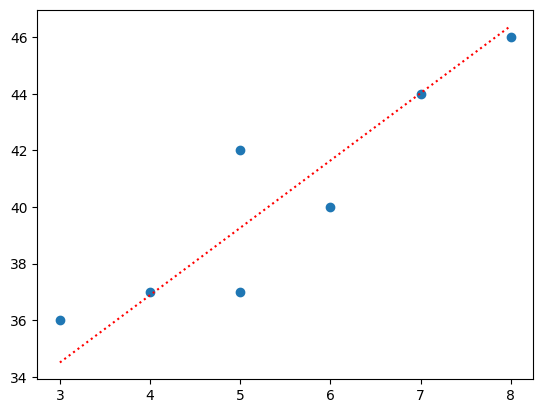

In [10]:
plt.scatter(x,y)

x_test = np.arange(3,8,0.01)
y_test = b + w*x_test

plt.plot(x_test, y_test, c='red', linestyle=':')
plt.show()

<Axes: xlabel='petal_length', ylabel='petal_width'>

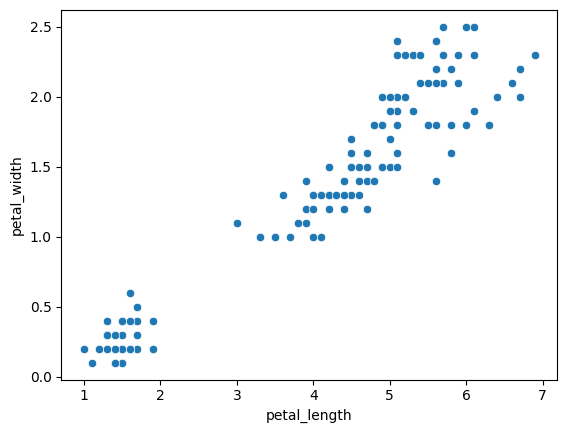

In [11]:
import seaborn as sns
iris = sns.load_dataset('iris')
sns.scatterplot(data=iris, x='petal_length', y='petal_width')

In [12]:
v_pl = np.var(iris['petal_length'])
v_pw = np.var(iris['petal_width'])
cv = np.cov(iris['petal_length'], iris['petal_width'])[0,1]

w=cv/v_pl
b=iris['petal_width'].mean() - iris['petal_length'].mean()*w

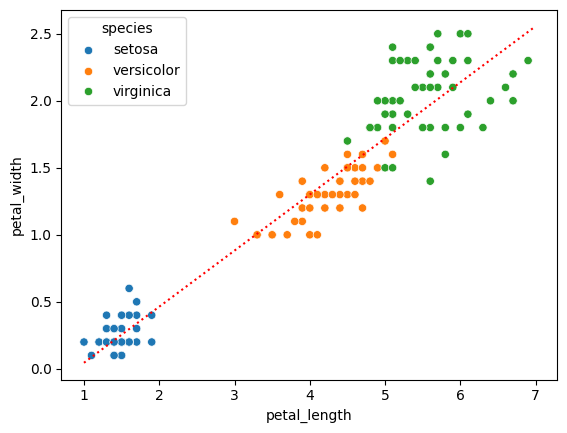

In [13]:
x_test = np.arange(1,7,0.01)
y_test = b + w*x_test

sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
plt.plot(x_test, y_test, c='red', linestyle=':')
plt.show()


### How do we know if our model is good?

MAE (Mean Absolute Error), SSE (Sum Squared), MSE (Mean Squared), RMSE (Root Mean Squared), RMSLE (Root Mean Squared Logrithmic)

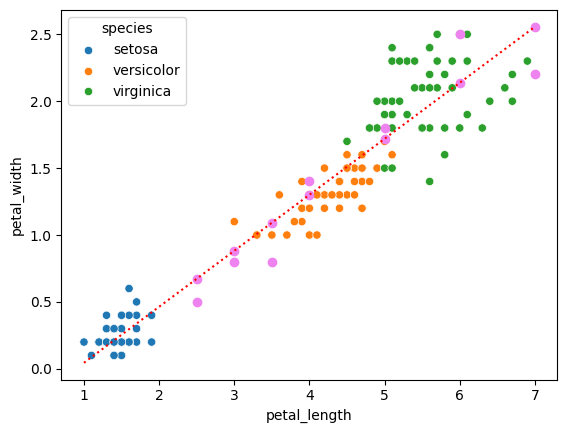

In [14]:
x_new = np.array([5,4,7, 3.5,3,2.5,6])
y_new = np.array([1.8, 1.4, 2.2, 0.8, 0.8, 0.5, 2.5])
y_pred = b + w*x_new

sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
plt.plot(x_test, y_test, c='red', linestyle=':')
plt.scatter(x_new, y_new, c='violet')
plt.scatter(x_new, y_pred, c='violet')
plt.show()

In [15]:
def rmse(true, pred):
    return np.sqrt(np.mean((true-pred)**2))

rmse(y_new, y_pred)

np.float64(0.23786653221771126)

# Goodness of fit

**MAE**  
**MSE**  
**RMSE**  
**RSS** (Risidual Sum of Squares aka Sum of squared errors)  
- RSS = SSE = $\sum (y - \hat y)^2$  
**RSE** - Residual Squared Error  
- RSE = $\sqrt {\frac {RSS} {n-2}}$  
**R^2**  
- R = corr(X,Y) = $ \frac {cov(X,Y)} {\sigma_x \sigma_y} = \frac {cov(X,Y)} {\sqrt {var(X)var(Y)}}$
- $R^2 = \frac {(cov(X,Y))^2} {var(X)var(Y)}$
- Describes how much of the variance in the Y variable can be attributed to the X variable
- For example:
    - X: # of police on the force
    - Y: Crime rate
    - R^2 = 0.84
    - 84% of the variation in crime rate can be attributed to the strength of the police force

# Project

project day on Wednesday